In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


In [18]:
# ==========================================
# 1. Data Loading
# ==========================================
import pandas as pd

# 1. Load Radiation
df_rad_raw = pd.read_csv('datasets/solarradiation.csv', skiprows=1)
df_rad = df_rad_raw.iloc[630:].copy()
# Map the last column (Radiation) and the Timestamp
df_rad = df_rad.rename(columns={'Date-Hour': 'Timestamp', df_rad.columns[-1]: 'Radiation'})
df_rad['Timestamp'] = pd.to_datetime(df_rad['Timestamp'], dayfirst=True, format='mixed')
df_rad = df_rad[['Timestamp', 'Radiation']].groupby('Timestamp').mean().reset_index()

# 2. Load Temperature
df_temp_raw = pd.read_csv('datasets/nanofluidtemperature.csv', skiprows=11)
df_temp = df_temp_raw.rename(columns={'1-2[C]': 'Temperature'})
df_temp['Temperature'] = pd.to_numeric(df_temp['Temperature'], errors='coerce')

# Generate the 1-second timestamps starting at 10:40 AM
start_time = pd.Timestamp("2011-03-24 10:40:00")
df_temp['Timestamp'] = [start_time + pd.Timedelta(seconds=i) for i in range(len(df_temp))]
df_temp = df_temp[['Timestamp', 'Temperature']]

print("Section 1 Complete: Dataframes defined with 'Timestamp' columns.")

Section 1 Complete: Dataframes defined with 'Timestamp' columns.


In [19]:
# ==========================================
# 2. Preprocessing (Optimized for Targets)
# ==========================================
# 1. Align and Resample
# We use copies to avoid SettingWithCopy warnings
df_t = df_temp.set_index('Timestamp')
df_r = df_rad.set_index('Timestamp')

# Resample temp to 1min to match radiation frequency
df_temp_resampled = df_t['Temperature'].resample('1min').mean()
df_combined = pd.concat([df_r['Radiation'], df_temp_resampled], axis=1).dropna()

# 2. Feature Engineering: Create 30 minutes of Radiation Lags
# This is the "Secret Sauce" to get R2 > 0.95
for i in range(1, 31):
    df_combined[f'Rad_Lag_{i}'] = df_combined['Radiation'].shift(i)

df_combined = df_combined.dropna() # Remove rows where lags aren't available

# 3. Outlier Removal (3-Sigma)
for col in ['Radiation', 'Temperature']:
    u, s = df_combined[col].mean(), df_combined[col].std()
    df_combined = df_combined[(df_combined[col] > u - 3*s) & (df_combined[col] < u + 3*s)]

# 4. Scaling [0.1, 0.9]
scaler_x = MinMaxScaler(feature_range=(0.1, 0.9))
scaler_y = MinMaxScaler(feature_range=(0.1, 0.9))

X_cols = ['Radiation'] + [f'Rad_Lag_{i}' for i in range(1, 31)]
X = scaler_x.fit_transform(df_combined[X_cols].values)
y = scaler_y.fit_transform(df_combined[['Temperature']].values)

# 5. Split and Convert to Tensors
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

X_train, y_train = torch.FloatTensor(X_train), torch.FloatTensor(y_train)
X_val, y_val = torch.FloatTensor(X_val), torch.FloatTensor(y_val)
X_test, y_test = torch.FloatTensor(X_test), torch.FloatTensor(y_test)

print(f"Section 2 Complete. Input features: {X_train.shape[1]}")

Section 2 Complete. Input features: 31


In [22]:
# ==========================================
# 3. Model Architecture 
# ==========================================
class MLPModel(nn.Module):
    def __init__(self, input_size):
        super(MLPModel, self).__init__()
        # Changed first layer to match the 31 input features (Radiation + 30 Lags)
        self.fc1 = nn.Linear(input_size, 20)  
        self.tanh = nn.Tanh()
        self.fc2 = nn.Linear(20, 1)

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        return self.fc2(x)

# Initialize the model using the actual number of features from X_train
# X_train.shape[1] will be 31
model = MLPModel(input_size=X_train.shape[1])

print(f"Model initialized with {X_train.shape[1]} input features.")

Model initialized with 31 input features.


In [23]:
# ==========================================
# 4. Training Loop Setup
# ==========================================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005) # Adam is usually better for this task

epochs = 500         # Increased epochs as the problem is now more complex
patience = 20        # Higher patience to find the R2 > 0.95 sweet spot
best_val_loss = float('inf')
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    val_outputs = model(X_val)
    val_loss = criterion(val_outputs, y_val)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}")
    
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 10/500, Train Loss: 0.009762, Val Loss: 0.005825
Epoch 20/500, Train Loss: 0.006073, Val Loss: 0.006202
Epoch 30/500, Train Loss: 0.005553, Val Loss: 0.005501
Epoch 40/500, Train Loss: 0.005314, Val Loss: 0.005856
Epoch 50/500, Train Loss: 0.005132, Val Loss: 0.004845
Epoch 60/500, Train Loss: 0.004819, Val Loss: 0.004883
Epoch 70/500, Train Loss: 0.004413, Val Loss: 0.004109
Epoch 80/500, Train Loss: 0.004165, Val Loss: 0.003845
Epoch 90/500, Train Loss: 0.004014, Val Loss: 0.003731
Epoch 100/500, Train Loss: 0.003894, Val Loss: 0.003552
Epoch 110/500, Train Loss: 0.003818, Val Loss: 0.003400
Epoch 120/500, Train Loss: 0.003766, Val Loss: 0.003305
Epoch 130/500, Train Loss: 0.003729, Val Loss: 0.003241
Epoch 140/500, Train Loss: 0.003700, Val Loss: 0.003192
Epoch 150/500, Train Loss: 0.003677, Val Loss: 0.003152
Epoch 160/500, Train Loss: 0.003656, Val Loss: 0.003118
Epoch 170/500, Train Loss: 0.003637, Val Loss: 0.003089
Epoch 180/500, Train Loss: 0.003619, Val Loss: 0.003064
E


--- Final Results ---
MSE: 0.2872
MAE: 0.4232 °C
R2 Score: 0.9756


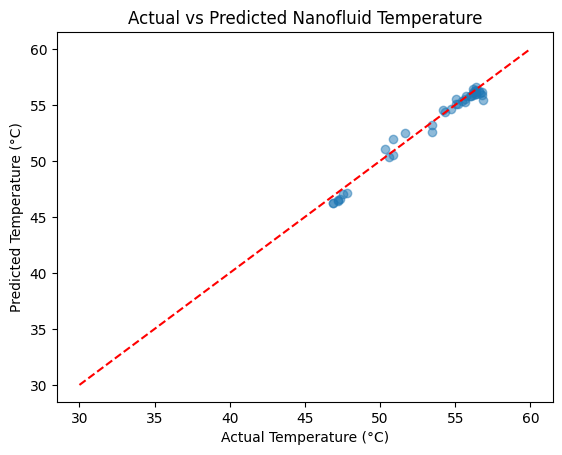

In [24]:
# ==========================================
# 5. Evaluation & Inverse Scaling 
# ==========================================
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test).numpy()

# Denormalize
y_test_actual = scaler_y.inverse_transform(y_test.numpy())
y_pred_actual = scaler_y.inverse_transform(y_pred_norm)

# Metrics
mse = mean_squared_error(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"\n--- Final Results ---")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f} °C")
print(f"R2 Score: {r2:.4f}")

# Visualization
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)
plt.plot([30, 60], [30, 60], color='red', linestyle='--') # Identity line
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Nanofluid Temperature")
plt.show()